C:\Users\veron\AppData\Local\Temp\ipykernel_32544\3461691515.py:29: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

Using ID column: id_patient


C:\Users\veron\AppData\Local\Temp\ipykernel_32544\3461691515.py:81: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

Rows: 24497


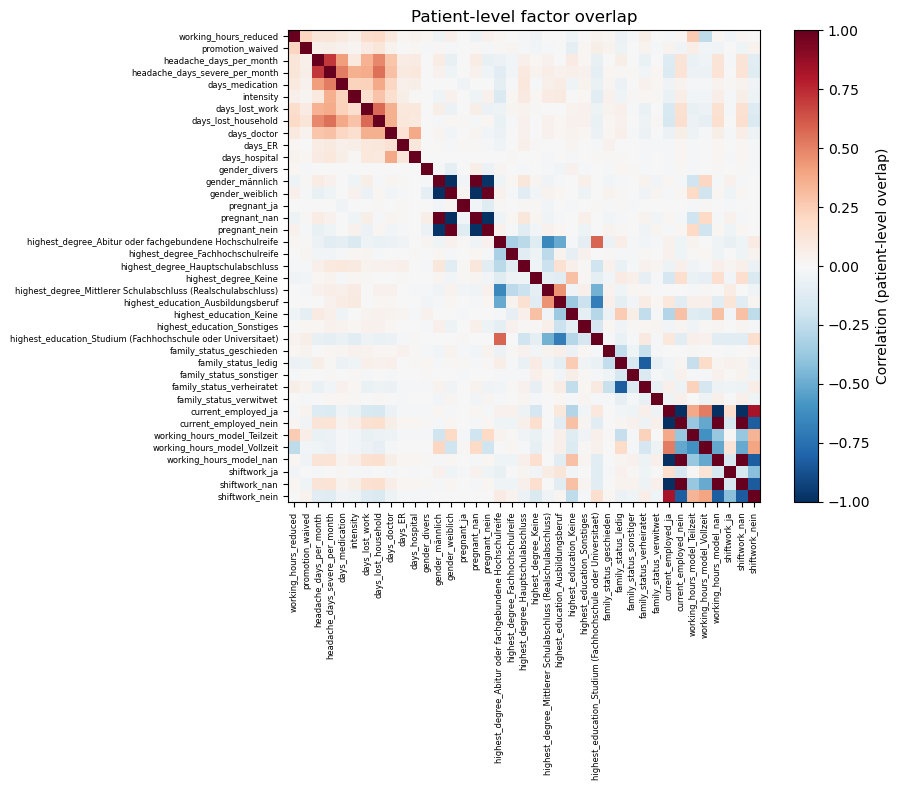


Top overlaps:
current_employed_ja                                      current_employed_nein                                          -1.000000
                                                         working_hours_model_nan                                        -1.000000
current_employed_nein                                    working_hours_model_nan                                         1.000000
                                                         shiftwork_nan                                                   0.997518
working_hours_model_nan                                  shiftwork_nan                                                   0.997518
current_employed_ja                                      shiftwork_nan                                                  -0.997518
gender_weiblich                                          pregnant_nan                                                   -0.997447
gender_männlich                                          pregnant_nan      

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# =========================================================
# CONFIG
# =========================================================

DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))

factor_prefixes = [
    "gender","pregnant",
    "highest_degree","highest_education","family_status",
    "current_employed","working_hours_model","shiftwork",
    "working_hours_reduced","promotion_waived",
    "headache_days_per_month","headache_days_severe_per_month",
    "days_medication","intensity","days_lost_work",
    "days_lost_household","days_doctor","days_ER","days_hospital"
]

# =========================================================
# LOAD DATA
# =========================================================

df = pd.concat(
    [pd.read_csv(f, sep=";", quotechar='"') for f in csv_files],
    ignore_index=True
)

# clean column names
df.columns = (
    df.columns
    .str.replace('"', '', regex=False)
    .str.replace('\ufeff', '', regex=False)
    .str.strip()
)

# robust ID detection
id_candidates = [c for c in df.columns if "id" in c.lower()]
if not id_candidates:
    raise ValueError("No ID column found")
ID_COL = id_candidates[0]

print("Using ID column:", ID_COL)

# =========================================================
# HELPERS
# =========================================================

def collapse_k_columns(df, prefixes):
    out = {}

    for p in prefixes:
        cols = [c for c in df.columns if c.startswith(p)]
        if not cols:
            continue

        block = df[cols]

        sample = block.stack().dropna()
        numeric_ratio = pd.to_numeric(sample, errors="coerce").notna().mean()

        if numeric_ratio > 0.7:
            num_block = block.apply(pd.to_numeric, errors="coerce")
            out[p] = num_block.mean(axis=1)
        else:
            out[p] = block.bfill(axis=1).iloc[:, 0].astype(str)

    return pd.DataFrame(out)

# =========================================================
# LOAD + COLLAPSE ALL FILES
# =========================================================

frames = []

for file in csv_files:
    d = pd.read_csv(file, sep=";", quotechar='"')

    d.columns = (
        d.columns
        .str.replace('"', '', regex=False)
        .str.replace('\ufeff', '', regex=False)
        .str.strip()
    )

    collapsed = collapse_k_columns(d, factor_prefixes)

    if ID_COL in d.columns:
        collapsed[ID_COL] = d[ID_COL].values
    else:
        continue

    frames.append(collapsed)

data = pd.concat(frames, ignore_index=True)

print("Rows:", len(data))

# =========================================================
# COLLAPSE TO PATIENT LEVEL
# =========================================================

patient = data.groupby(ID_COL).first().reset_index()

# =========================================================
# ONE-HOT ENCODE CATEGORICAL COLUMNS (NaN SAFE)
# =========================================================

numeric_cols = []
cat_dfs = []

for col in patient.columns:
    if col == ID_COL:
        continue

    series = patient[col]

    # drop real NaNs early for categorical handling
    series_clean = series.dropna()

    numeric = pd.to_numeric(series_clean, errors="coerce")
    numeric_ratio = numeric.notna().mean() if len(numeric) > 0 else 0

    if numeric_ratio > 0.7:
        patient[col] = pd.to_numeric(series, errors="coerce")
        numeric_cols.append(col)

    else:
        # categorical → one-hot (NaN excluded)
        dummies = pd.get_dummies(series.astype("object"), prefix=col, dummy_na=False)
        cat_dfs.append(dummies)

# combine
X = pd.concat([patient[numeric_cols]] + cat_dfs, axis=1)

# =========================================================
# STRICT NaN REMOVAL BEFORE CORRELATION
# =========================================================

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna(axis=0, how="any")   # remove patients with ANY missing value
X = X.dropna(axis=1, how="any")   # remove features with ANY missing value

# =========================================================
# CORRELATION MATRIX
# =========================================================

corr = X.corr()

# =========================================================
# PLOT HEATMAP
# =========================================================

plt.figure(figsize=(10, 8))

cmap="RdBu_r"

plt.imshow(
    corr,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)
plt.colorbar(label="Correlation (patient-level overlap)")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr.index)), corr.index, fontsize=6)

plt.title("Patient-level factor overlap")

plt.tight_layout()
plt.show()

# =========================================================
# OPTIONAL: TOP CORRELATIONS
# =========================================================

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=abs, ascending=False)
)

print("\nTop overlaps:")
print(corr_pairs.head(20))

C:\Users\veron\AppData\Local\Temp\ipykernel_11568\1588820568.py:60: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

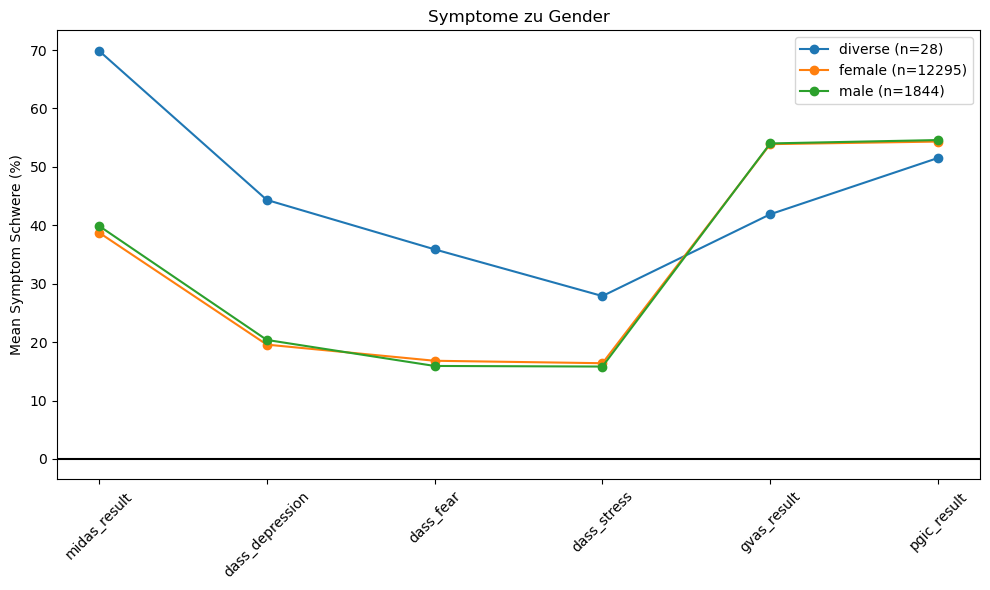

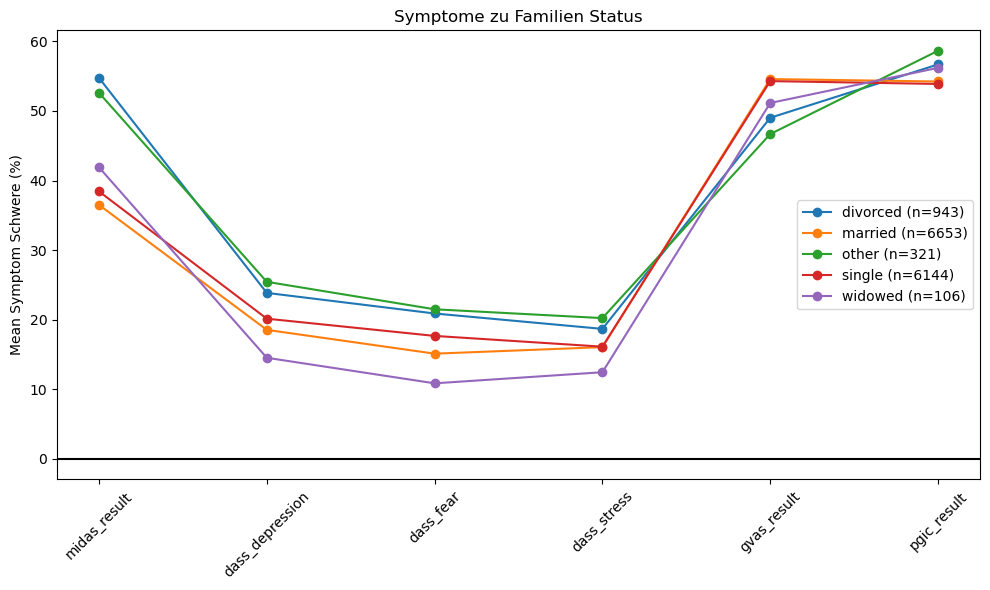

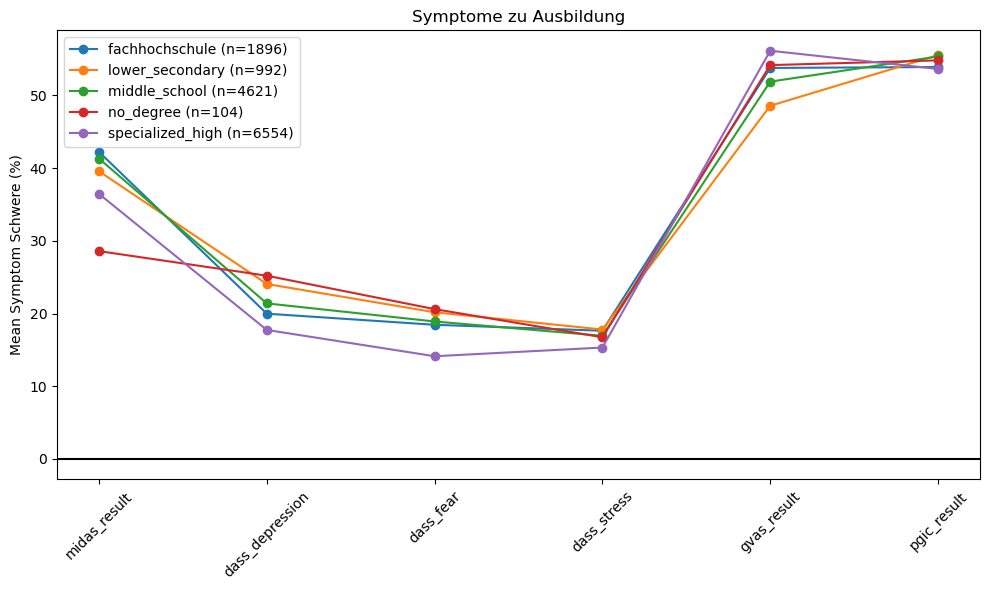

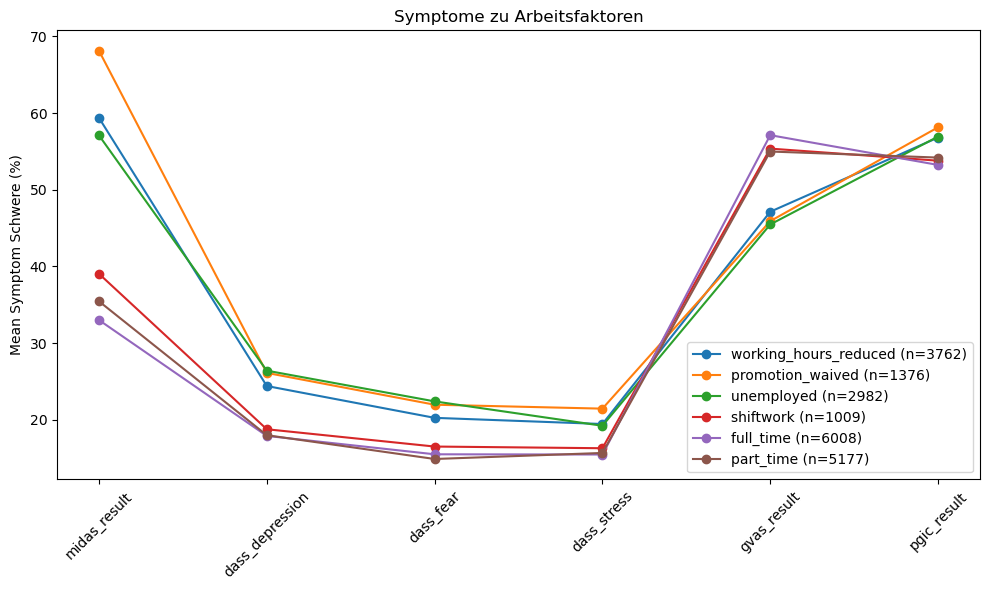

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================

DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))

score_bases = [
    "midas_result",
    "dass_depression",
    "dass_fear",
    "dass_stress",
    "gvas_result",
    "pgic_result"
]

score_ranges = {
    "pgic_result": 7,
    "dass_depression": 24,
    "dass_fear": 21,
    "dass_stress": 42,
    "gvas_result": 100,
    "midas_result": 90
}

# =========================================================
# HELPERS (unchanged)
# =========================================================

def first_nonempty(df, prefix):
    cols = [c for c in df.columns if c.startswith(prefix)]
    if not cols:
        return None
    return df[cols].bfill(axis=1).iloc[:, 0]

def norm(s):
    return s.astype(str).str.lower().str.strip()

K_VALUES = ["k", "ka", "k.a.", "ka.", "keine angabe", "n/a", "na", ""]

def clean_numeric(df):
    return (
        df.replace(K_VALUES, np.nan)
          .apply(pd.to_numeric, errors="coerce")
    )

# =========================================================
# BUILD DATASET (unchanged core logic)
# =========================================================

frames = []

for file in csv_files:

    df = pd.read_csv(file, sep=";")

    df.columns = (
        df.columns.str.replace('"', '', regex=False)
        .str.replace('\ufeff', '', regex=False)
        .str.strip()
    )

    out = {}

    # ---------------- SCORES ----------------
    for base in score_bases:
        cols = [c for c in df.columns if c.startswith(base)]
        if cols:
            score_df = clean_numeric(df[cols])
            out[base] = score_df.mean(axis=1, skipna=True)

    # ---------------- DEMOGRAPHICS ----------------
    g = first_nonempty(df, "gender")
    if g is not None:
        g = norm(g)
        out["gender"] = np.select(
            [
                g.str.contains("männlich|male"),
                g.str.contains("weiblich|female"),
                g.str.contains("divers|other")
            ],
            ["male", "female", "diverse"],
            default="unknown"
        )

    f = first_nonempty(df, "family_status")
    if f is not None:
        f = norm(f)
        out["family_status"] = np.select(
            [
                f.str.contains("verheiratet"),
                f.str.contains("ledig"),
                f.str.contains("geschieden"),
                f.str.contains("verwitwet"),
                f.str.contains("sonst")
            ],
            ["married", "single", "divorced", "widowed", "other"],
            default="unknown"
        )

    e = first_nonempty(df, "highest_degree")
    if e is not None:
        e = norm(e)
        out["education"] = np.select(
            [
                e.str.contains("keine"),
                e.str.contains("haupt"),
                e.str.contains("mittler"),
                e.str.contains("fachhoch"),
                e.str.contains("fachgeb"),
                e.str.contains("abitur")
            ],
            [
                "no_degree",
                "lower_secondary",
                "middle_school",
                "fachhochschule",
                "specialized_high",
                "abitur"
            ],
            default="other"
        )

    # ---------------- WORK ----------------
    def bin_yes_no(series):
        s = norm(series)
        return s.str.contains("ja|yes|true|1").astype(int)

    whr = first_nonempty(df, "working_hours_reduced")
    if whr is not None:
        out["working_hours_reduced"] = bin_yes_no(whr)

    pw = first_nonempty(df, "promotion_waived")
    if pw is not None:
        out["promotion_waived"] = bin_yes_no(pw)

    ce = first_nonempty(df, "current_employed")
    if ce is not None:
        out["unemployed"] = norm(ce).str.contains("nein|no|0").astype(int)

    shift = first_nonempty(df, "shiftwork")
    if shift is not None:
        out["shiftwork"] = bin_yes_no(shift)

    whm = first_nonempty(df, "working_hours_model")
    if whm is not None:
        w = norm(whm)
        out["full_time"] = w.str.contains("vollzeit").astype(int)
        out["part_time"] = w.str.contains("teilzeit").astype(int)

    frames.append(pd.DataFrame(out))

data = pd.concat(frames, ignore_index=True)
data = data.dropna(subset=score_bases)

# scale
for b in score_bases:
    data[b] = (data[b] / score_ranges[b]) * 100

def plot_group(col, title):

    if col not in data.columns:
        return

    plt.figure(figsize=(10, 6))

    for g in sorted(data[col].dropna().unique()):
        sub = data[data[col] == g]

        means = [sub[b].mean() for b in score_bases]

        # 🔥 NEW: sample size (N)
        n = len(sub)

        plt.plot(
            score_bases,
            means,
            marker="o",
            label=f"{g} (n={n})"
        )

    plt.axhline(0, color="black")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.ylabel("Mean Symptom Schwere (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================================================
# VISUALS (unchanged calls)
# =========================================================

plot_group("gender", "Symptome zu Gender")
plot_group("family_status", "Symptome zu Familien Status")
plot_group("education", "Symptome zu Ausbildung")

plt.figure(figsize=(10, 6))

work_vars = [
    "working_hours_reduced",
    "promotion_waived",
    "unemployed",
    "shiftwork",
    "full_time",
    "part_time"
]

for w in work_vars:
    if w in data.columns:
        sub = data[data[w] == 1]
        means = [sub[b].mean() for b in score_bases]

        plt.plot(score_bases, means, marker="o", label=f"{w} (n={len(sub)})")

plt.title("Symptome zu Arbeitsfaktoren")
plt.xticks(rotation=45)
plt.ylabel("Mean Symptom Schwere (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
# =========================================================
# FRAGEBOGENWERTE NACH GENDER
# =========================================================

if "gender" in data.columns:

    gender_questionnaire_values = (
        data
        .groupby("gender")[score_bases]
        .agg(["mean", "std", "count"])
        .round(2)
    )

    print("\n" + "=" * 80)
    print("FRAGEBOGENWERTE NACH GENDER")
    print("=" * 80)

    print(gender_questionnaire_values)

    # Zusätzlich übersichtliche Ausgabe pro Gender
    for gender_value in sorted(data["gender"].dropna().unique()):

        sub = data[data["gender"] == gender_value]

        print("\n" + "-" * 80)
        print(f"GENDER: {gender_value} (n={len(sub)})")
        print("-" * 80)

        for questionnaire in score_bases:
            print(
                f"{questionnaire}: "
                f"Mittelwert = {sub[questionnaire].mean():.2f} %, "
                f"SD = {sub[questionnaire].std():.2f}, "
                f"N = {sub[questionnaire].count()}"
            )


FRAGEBOGENWERTE NACH GENDER
        midas_result               dass_depression               dass_fear  \
                mean    std  count            mean    std  count      mean   
gender                                                                       
diverse        69.88  65.50     28           44.35  19.35     28     35.88   
female         38.76  51.28  12295           19.58  20.30  12295     16.81   
male           39.91  59.16   1844           20.38  19.77   1844     15.93   

                      dass_stress               gvas_result                \
           std  count        mean    std  count        mean    std  count   
gender                                                                      
diverse  28.35     28       27.89  11.68     28       41.89  16.95     28   
female   18.57  12295       16.39  12.07  12295       53.89  21.78  12295   
male     18.43   1844       15.82  12.16   1844       54.02  22.75   1844   

        pgic_result                
   

In [7]:
# =========================================================
# FRAGEBOGENWERTE NACH ARBEITSFAKTOR-GRUPPEN
# =========================================================

# Gruppe 1:
# shiftwork, full_time, part_time

# Gruppe 2:
# working_hours_reduced, promotion_waived, unemployed

group_1_vars = [
    "shiftwork",
    "full_time",
    "part_time"
]

group_2_vars = [
    "working_hours_reduced",
    "promotion_waived",
    "unemployed"
]

# Personen gehören zur Gruppe, wenn mindestens ein Faktor = 1 ist
group_1_mask = data[group_1_vars].eq(1).any(axis=1)
group_2_mask = data[group_2_vars].eq(1).any(axis=1)

group_1 = data[group_1_mask]
group_2 = data[group_2_mask]

# Zusammenfassung erstellen
group_results = []

for group_name, group_data in [
    ("Gruppe 1: Shiftwork / Full-Time / Part-Time", group_1),
    ("Gruppe 2: Reduced Hours / Promotion Waived / Unemployed", group_2)
]:

    for questionnaire in score_bases:

        group_results.append({
            "Gruppe": group_name,
            "Fragebogen": questionnaire,
            "Mean": group_data[questionnaire].mean(),
            "Std": group_data[questionnaire].std(),
            "Count": group_data[questionnaire].count()
        })

group_results_df = pd.DataFrame(group_results)

# Werte runden
group_results_df["Mean"] = group_results_df["Mean"].round(2)
group_results_df["Std"] = group_results_df["Std"].round(2)

print("\n" + "=" * 100)
print("FRAGEBOGENWERTE NACH ARBEITSFAKTOR-GRUPPEN")
print("=" * 100)

print(group_results_df.to_string(index=False))


FRAGEBOGENWERTE NACH ARBEITSFAKTOR-GRUPPEN
                                                 Gruppe      Fragebogen  Mean   Std  Count
            Gruppe 1: Shiftwork / Full-Time / Part-Time    midas_result 34.15 45.17  11187
            Gruppe 1: Shiftwork / Full-Time / Part-Time dass_depression 17.95 19.11  11187
            Gruppe 1: Shiftwork / Full-Time / Part-Time       dass_fear 15.23 17.62  11187
            Gruppe 1: Shiftwork / Full-Time / Part-Time     dass_stress 15.58 11.86  11187
            Gruppe 1: Shiftwork / Full-Time / Part-Time     gvas_result 56.12 21.12  11187
            Gruppe 1: Shiftwork / Full-Time / Part-Time     pgic_result 53.68 18.99  11187
Gruppe 2: Reduced Hours / Promotion Waived / Unemployed    midas_result 54.27 62.81   6429
Gruppe 2: Reduced Hours / Promotion Waived / Unemployed dass_depression 24.52 22.02   6429
Gruppe 2: Reduced Hours / Promotion Waived / Unemployed       dass_fear 20.60 20.17   6429
Gruppe 2: Reduced Hours / Promotion Waived / U

In [11]:
# ---------------- FAMILY STATUS ----------------
f = first_nonempty(df, "family_status")

if f is not None:

    f = norm(f)

    out["family_status"] = np.select(
        [
            f.str.contains("verheiratet|married", na=False),
            f.str.contains("ledig|single", na=False),
            f.str.contains("geschieden|divorc", na=False),
            f.str.contains("verwitwet|widow", na=False),
            f.str.contains("sonst|other", na=False)
        ],
        [
            "married",
            "single",
            "divorced",
            "widowed",
            "other"
        ],
        default="unknown"
    )

In [12]:
# =========================================================
# FRAGEBOGENWERTE NACH FAMILIENSTATUS
# =========================================================

family_groups = {
    "Gruppe 1: Other + Divorced": ["other", "divorced"],
    "Gruppe 2: Married + Single": ["married", "single"],
    "Gruppe 3: Widowed": ["widowed"]
}

print("\n" + "=" * 80)
print("FRAGEBOGENWERTE NACH FAMILIENSTATUS")
print("=" * 80)

for group_name, statuses in family_groups.items():

    group_data = data[data["family_status"].isin(statuses)]

    print("\n" + "-" * 80)
    print(group_name)
    print("-" * 80)

    for questionnaire in score_bases:

        mean_value = group_data[questionnaire].mean()
        sd_value = group_data[questionnaire].std()
        n_value = group_data[questionnaire].count()

        print(
            f"{questionnaire}: "
            f"Mittelwert = {mean_value:.2f} %, "
            f"SD = {sd_value:.2f}, "
            f"N = {n_value}"
        )


FRAGEBOGENWERTE NACH FAMILIENSTATUS

--------------------------------------------------------------------------------
Gruppe 1: Other + Divorced
--------------------------------------------------------------------------------
midas_result: Mittelwert = 54.21 %, SD = 60.96, N = 1264
dass_depression: Mittelwert = 24.27 %, SD = 21.77, N = 1264
dass_fear: Mittelwert = 21.06 %, SD = 20.11, N = 1264
dass_stress: Mittelwert = 19.09 %, SD = 12.59, N = 1264
gvas_result: Mittelwert = 48.43 %, SD = 22.41, N = 1264
pgic_result: Mittelwert = 57.19 %, SD = 20.34, N = 1264

--------------------------------------------------------------------------------
Gruppe 2: Married + Single
--------------------------------------------------------------------------------
midas_result: Mittelwert = 37.44 %, SD = 51.28, N = 12797
dass_depression: Mittelwert = 19.32 %, SD = 20.08, N = 12797
dass_fear: Mittelwert = 16.36 %, SD = 18.40, N = 12797
dass_stress: Mittelwert = 16.10 %, SD = 12.02, N = 12797
gvas_result: 

In [13]:
# =========================================================
# FAMILIENSTATUS – KOMPAKTE AUSGABE ALS TABELLE
# =========================================================

results_family = []

for group_name, statuses in family_groups.items():

    group_data = data[data["family_status"].isin(statuses)]

    for questionnaire in score_bases:

        results_family.append({
            "Gruppe": group_name,
            "Fragebogen": questionnaire,
            "Mean (%)": group_data[questionnaire].mean(),
            "SD": group_data[questionnaire].std(),
            "N": group_data[questionnaire].count()
        })

family_results_df = pd.DataFrame(results_family)

print(family_results_df.round(2).to_string(index=False))

                    Gruppe      Fragebogen  Mean (%)    SD     N
Gruppe 1: Other + Divorced    midas_result     54.21 60.96  1264
Gruppe 1: Other + Divorced dass_depression     24.27 21.77  1264
Gruppe 1: Other + Divorced       dass_fear     21.06 20.11  1264
Gruppe 1: Other + Divorced     dass_stress     19.09 12.59  1264
Gruppe 1: Other + Divorced     gvas_result     48.43 22.41  1264
Gruppe 1: Other + Divorced     pgic_result     57.19 20.34  1264
Gruppe 2: Married + Single    midas_result     37.44 51.28 12797
Gruppe 2: Married + Single dass_depression     19.32 20.08 12797
Gruppe 2: Married + Single       dass_fear     16.36 18.40 12797
Gruppe 2: Married + Single     dass_stress     16.10 12.02 12797
Gruppe 2: Married + Single     gvas_result     54.45 21.78 12797
Gruppe 2: Married + Single     pgic_result     54.07 18.95 12797
         Gruppe 3: Widowed    midas_result     41.91 49.01   106
         Gruppe 3: Widowed dass_depression     14.54 15.99   106
         Gruppe 3: Widowe